## Working File to Test and Run Code Segments

# Function to change image resolution to desired size


Sharpening: (455, 455) vs [256, 256]
Sharpening: (361, 361) vs [256, 256]
(228, 228, 3)


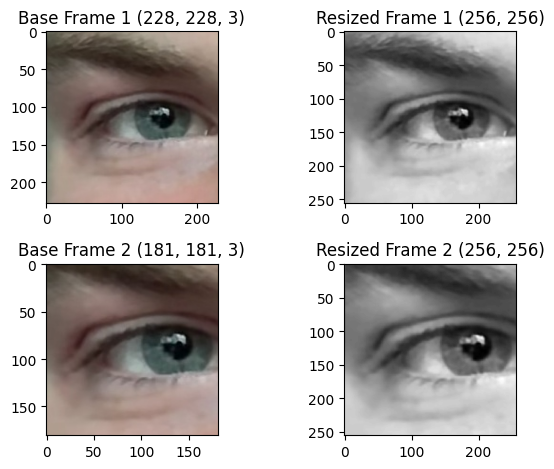

In [1]:
import numpy 
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
import os

def blur_and_sample(img, a=0.4):
    # Enter your code here
    
    # build Gaussian Mask
    gaussMask = numpy.array([[.25-.5*a, .25, a, .25, .25-.5*a]])
    gaussMask = gaussMask / gaussMask.sum()
    #print(gaussMask, gaussMask.shape) # debugging
    #print(img.shape)

    # correlate row-wise
    rowBlurred = ndimage.correlate(img, gaussMask)
    blurred = ndimage.correlate(rowBlurred, gaussMask.T)

    # initialize new photo
    nRows = int(numpy.ceil(img.shape[0] / 2))
    nCols = int(numpy.ceil(img.shape[1] / 2))
    downsampled_img = numpy.zeros([nRows, nCols])

    # sample pixels for the downsampled image
    for row in range(0, nRows):
        for col in range(0, nCols):
            bRow = row*2
            bCol = col*2
            downsampled_img[row, col] = numpy.mean(blurred[bRow:bRow+1, bCol:bCol+1])
    
    return downsampled_img

def sharpen(img):
    # Enter your code here
    
    # initialize new photo
    nRows = int(img.shape[0] * 2 - 1)
    nCols = int(img.shape[1] * 2 - 1)
    upsampled_img = numpy.zeros([nRows, nCols])
    
    # assign odd (even index) row,col values to correspond to known values
    for row in range(0, nRows, 2):
        for col in range(0, nCols, 2):
            upsampled_img[row, col] = img[int(row/2)-1, int(col/2)-1]

    # assign even (odd index) row,col values using interpolation
    for row in range(1, nRows, 2):
        for col in range(1, nCols, 2):
            inputRow = int((row - 1) / 2)
            inputCol = int((col - 1)/ 2)
            upsampled_img[row, col] = numpy.mean(img[inputRow:inputRow+1, inputCol:inputCol+1])

    return upsampled_img

def downsample_to_ideal(image, ideal_shape = [256,256], a=0.4):
# Function that an image as an input and updates the resolution of each image to make the ideal shape. 
# Uses downsampling to decrease resolution
# Inputs:
#   image: A square image that is larger or equal to the ideal_shape image, but not more than twice the size
#   ideal_shape: The desired dimensions of each image. Has a default value to match the ML model expected input
# Outputs:  
#   resized_image: The image resized to the ideal_shape


    # initialize new photo
    resized_image = numpy.zeros(ideal_shape)

    # scaling factor
    scale_factor = ideal_shape[0] / image.shape[0]
    # print(scale_factor)

    # build Gaussian Mask
    gaussMask = numpy.array([[.25-.5*a, .25, a, .25, .25-.5*a]])
    gaussMask = gaussMask / gaussMask.sum()
    #print(gaussMask, gaussMask.shape) # debugging
    #print(img.shape)

    # correlate row-wise
    rowBlurred = ndimage.correlate(image, gaussMask)
    blurred = ndimage.correlate(rowBlurred, gaussMask.T)

    # downsample to fill the photo
    for row in range(0, ideal_shape[0]):
        for col in range(0, ideal_shape[1]):

            # translate row and col number to original image
            original_row = row / scale_factor
            original_row_rounded = int(round(original_row, 0))
            original_row_rerror = original_row - original_row_rounded

            original_col = col / scale_factor
            original_col_rounded = int(round(original_col, 0))
            original_col_rerror = original_col - original_col_rounded

            # take gaussian average based on distance from actual value: 
            resized_image[row, col] = blurred[original_row_rounded, original_col_rounded]

    return resized_image



def change_resolution(image, ideal_shape = [256,256], testing=False, saving=False):
# Function that takes an array of images as an input and updates the resolution of each image to make the ideal shape. 
# Uses blurring or reverse blurring/sharpening to decrease and increase resolution (respectively)
# Inputs:
#   images: An array of images
#   ideal_shape: The desired dimensions of each image. Has a default value to match the ML model expected input
# Outputs:  
#   resized_images: The image array where each image has been resized to the ideal_shape

    # first, reduce to grayscale
    image = numpy.array(image).astype('uint8')
    resized_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # while loop to determine if image is correct size
    flag = True
    while(flag):
        if resized_image.shape[0] > ideal_shape[0] * 2: # if image is too large, blur and downsample
            if testing:
                print(f'Blurring: {resized_image.shape} vs {ideal_shape}')
            resized_image = blur_and_sample(resized_image)
        elif resized_image.shape[0] < ideal_shape[0]: # if image is too small, sharpen/interpolated it
            resized_image = sharpen(resized_image)
            if testing:
                print(f'Sharpening: {resized_image.shape} vs {ideal_shape}')
        else:
            resized_image = downsample_to_ideal(resized_image, ideal_shape)
            flag = False

    return resized_image

def change_resolution_frames(images, ideal_shape = [256,256], eye_type="left", testing=False, saving=False):
# Function that takes an array of images as an input and updates the resolution of each image to make the ideal shape. 
# Uses blurring or reverse blurring/sharpening to decrease and increase resolution (respectively)
# Inputs:
#   images: A LIST of images
#   ideal_shape: The desired dimensions of each image. Has a default value to match the ML model expected input
#   testing: prints helpful debugging outputs if true
#   eye_type: "left" or "right" - impacts file name if saving
#   saving: saves each image if true
# Outputs:  
#   resized_images: The image array where each image has been resized to the ideal_shape

    # create array to hold new images
    # save frame dimensions, use to initialize an array to store the frames
    frame_dim = list(ideal_shape)
    frame_dim.insert(0, len(images))
    resized_images = numpy.zeros(frame_dim).astype('uint8')

    # Create output directory if it doesn't exist
    output_dir = './cropped_eyes/'
    os.makedirs(output_dir, exist_ok=True)

    for frame in range(0, len(images)):
        this_frame = change_resolution(images[frame], ideal_shape, testing, saving)
        resized_images[frame,:,:] = this_frame

        if saving:
            output_path = os.path.join(output_dir, f"frame_{frame:04d}_{eye_type}_eye.jpg")
            cv2.imwrite(output_path, this_frame)
    
    return(resized_images)

image = cv2.imread('./frame_0000_left_eye.jpg')
image2 = cv2.imread('./frame_0005_left_eye.jpg')

images = list()
images.append(image)
images.append(image2)

corrected_image = numpy.zeros_like(image)
corrected_image[:,:,0] = image[:,:,2]
corrected_image[:,:,1] = image[:,:,1]
corrected_image[:,:,2] = image[:,:,0]

corrected_image2 = numpy.zeros_like(image2)
corrected_image2[:,:,0] = image2[:,:,2]
corrected_image2[:,:,1] = image2[:,:,1]
corrected_image2[:,:,2] = image2[:,:,0]

resized_images = change_resolution_frames(images, [256,256], testing=True, saving=True)

fig, ax = plt.subplots(2,2)
print(corrected_image.shape)
ax[0,0].imshow(corrected_image)
ax[0,0].set_title(f"Base Frame 1 {image.shape}")
ax[0,1].imshow(resized_images[0,:,:], cmap='gray')
ax[0,1].set_title(f"Resized Frame 1 {resized_images[0].shape}")
ax[1,0].imshow(corrected_image2)
ax[1,0].set_title(f"Base Frame 2 {image2.shape}")
ax[1,1].imshow(resized_images[1,:,:], cmap='gray')
ax[1,1].set_title(f"Resized Frame 2 {resized_images[1].shape}")
plt.tight_layout()

Update Eye Isolation Code using new 68 point method:

In [ ]:
import cv2
import dlib
import numpy as np
import time
from datetime import datetime
import pandas as pd
import os

class EyeTracker:
    def __init__(self, file=0):
        # Initialize face detector and facial landmark predictor
        self.detector = dlib.get_frontal_face_detector()
        self.predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
        
        # Initialize video capture
        self.cap = cv2.VideoCapture(file)
        self.cap.set(cv2.CAP_PROP_FPS, 30)
        
        # Storage for measurements
        self.measurements = []
        
        # Create a directory to save frames and measurements
        self.output_dir = "eye_tracking_output"
        os.makedirs(self.output_dir, exist_ok=True)
        
    def calculate_distance(self, point1, point2):
        """Calculate Euclidean distance between two points"""
        return np.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)
    
    def get_eye_measurements(self, frame):
        """Extract eye measurements from a single frame"""
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = self.detector(gray)
        
        for face in faces:
            landmarks = self.predictor(gray, face)
            
            # Get left eye landmarks
            left_eye_points = []
            for n in range(36, 42):
                x = landmarks.part(n).x
                y = landmarks.part(n).y
                left_eye_points.append((x, y))
            
            # Get right eye landmarks
            right_eye_points = []
            for n in range(42, 48):
                x = landmarks.part(n).x
                y = landmarks.part(n).y
                right_eye_points.append((x, y))
            
            # Calculate measurements for left eye
            left_upper_lid = left_eye_points[1]  # Point 37
            left_lower_lid = left_eye_points[4]  # Point 40
            left_pupil_center = (
                (left_eye_points[0][0] + left_eye_points[3][0]) // 2,
                (left_eye_points[1][1] + left_eye_points[4][1]) // 2
            )
            
            # Calculate distances for left eye
            left_palpebral_height = self.calculate_distance(left_upper_lid, left_lower_lid)
            left_pupil_to_lower = self.calculate_distance(left_pupil_center, left_lower_lid)
            
            # Calculate measurements for right eye
            right_upper_lid = right_eye_points[1]  # Point 43
            right_lower_lid = right_eye_points[4]  # Point 46
            right_pupil_center = (
                (right_eye_points[0][0] + right_eye_points[3][0]) // 2,
                (right_eye_points[1][1] + right_eye_points[4][1]) // 2
            )
            
            # Calculate distances for right eye
            right_palpebral_height = self.calculate_distance(right_upper_lid, right_lower_lid)
            right_pupil_to_lower = self.calculate_distance(right_pupil_center, right_lower_lid)
            
            # Draw measurements on frame
            cv2.line(frame, left_upper_lid, left_lower_lid, (0, 255, 0), 1)
            cv2.line(frame, left_pupil_center, left_lower_lid, (255, 0, 0), 1)
            cv2.line(frame, right_upper_lid, right_lower_lid, (0, 255, 0), 1)
            cv2.line(frame, right_pupil_center, right_lower_lid, (255, 0, 0), 1)
            
            # Draw points for left eye
            for point in left_eye_points:
                cv2.circle(frame, point, 2, (0, 0, 255), -1)  # Red dot for left eye
            cv2.circle(frame, left_pupil_center, 2, (255, 255, 0), -1)  # Yellow dot for left pupil
            
            # Draw points for right eye
            for point in right_eye_points:
                cv2.circle(frame, point, 2, (0, 0, 255), -1)  # Red dot for right eye
            cv2.circle(frame, right_pupil_center, 2, (255, 255, 0), -1)  # Yellow dot for right pupil
            
            # Create larger bounding boxes around eyes
            left_eye_rect = cv2.boundingRect(np.array(left_eye_points))
            right_eye_rect = cv2.boundingRect(np.array(right_eye_points))
            
            # Increase the size of the bounding box
            left_eye_rect = (left_eye_rect[0] - 20, left_eye_rect[1] - 10, 
                             left_eye_rect[2] + 40, left_eye_rect[3] + 20)  # Adjust as needed
            right_eye_rect = (right_eye_rect[0] - 20, right_eye_rect[1] - 10, 
                              right_eye_rect[2] + 40, right_eye_rect[3] + 20)  # Adjust as needed
            
            # Save the eye regions as images
            left_eye_image = frame[left_eye_rect[1]:left_eye_rect[1] + left_eye_rect[3], 
                                    left_eye_rect[0]:left_eye_rect[0] + left_eye_rect[2]]
            right_eye_image = frame[right_eye_rect[1]:right_eye_rect[1] + right_eye_rect[3], 
                                     right_eye_rect[0]:right_eye_rect[0] + right_eye_rect[2]]
            
            # Save the images to the output directory
            left_eye_filename = os.path.join(self.output_dir, f"left_eye_{int(time.time())}.jpg")
            right_eye_filename = os.path.join(self.output_dir, f"right_eye_{int(time.time())}.jpg")
            cv2.imwrite(left_eye_filename, left_eye_image)
            cv2.imwrite(right_eye_filename, right_eye_image)
            
            return frame, (left_palpebral_height, left_pupil_to_lower), (right_palpebral_height, right_pupil_to_lower)
        
        return frame, (None, None), (None, None)
    
    def run(self, duration=20):
        """Run eye tracking for live video"""
        start_time = time.time()
        
        while True:
            ret, frame = self.cap.read()
            if not ret:
                break
            
            current_time = time.time() - start_time
            
            # Process frame
            frame, left_measurements, right_measurements = self.get_eye_measurements(frame)
            
            if left_measurements[0] is not None and right_measurements[0] is not None:
                # Store measurements
                self.measurements.append({
                    'timestamp': current_time,
                    'left_palpebral_height': left_measurements[0],
                    'left_pupil_to_lower': left_measurements[1],
                    'right_palpebral_height': right_measurements[0],
                    'right_pupil_to_lower': right_measurements[1]
                })
                
                # Display measurements
                cv2.putText(frame, f"Left Palpebral Height: {left_measurements[0]:.2f}", 
                           (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                cv2.putText(frame, f"Left Pupil to Lower: {left_measurements[1]:.2f}", 
                           (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                cv2.putText(frame, f"Right Palpebral Height: {right_measurements[0]:.2f}", 
                           (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                cv2.putText(frame, f"Right Pupil to Lower: {right_measurements[1]:.2f}", 
                           (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
            cv2.imshow('Eye Tracking - Live', frame)
            
            # Exit conditions
            if cv2.waitKey(1) & 0xFF == ord('q') or (current_time >= duration and self.file == 0):
                break
        
        self.cleanup()
        self.save_measurements()

    def run_video(self, video_path):
        """Run eye tracking for uploaded video"""
        cap = cv2.VideoCapture(video_path)
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            # Process frame
            frame, left_measurements, right_measurements = self.get_eye_measurements(frame)
            
            if left_measurements[0] is not None and right_measurements[0] is not None:
                # Store measurements
                self.measurements.append({
                    'timestamp': cap.get(cv2.CAP_PROP_POS_MSEC) / 1000,  # Convert to seconds
                    'left_palpebral_height': left_measurements[0],
                    'left_pupil_to_lower': left_measurements[1],
                    'right_palpebral_height': right_measurements[0],
                    'right_pupil_to_lower': right_measurements[1]
                })
                
                # Display measurements
                cv2.putText(frame, f"Left Palpebral Height: {left_measurements[0]:.2f}", 
                           (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                cv2.putText(frame, f"Left Pupil to Lower: {left_measurements[1]:.2f}", 
                           (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                cv2.putText(frame, f"Right Palpebral Height: {right_measurements[0]:.2f}", 
                           (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                cv2.putText(frame, f"Right Pupil to Lower: {right_measurements[1]:.2f}", 
                           (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
            cv2.imshow('Eye Tracking - Video', frame)
            
            # Exit conditions
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        
        cap.release()
        self.save_measurements()

    def cleanup(self):
        """Release resources"""
        self.cap.release()
        cv2.destroyAllWindows()
    
    def save_measurements(self):
        """Save measurements to CSV file"""
        if self.measurements:
            df = pd.DataFrame(self.measurements)
            filename = os.path.join(self.output_dir, f"eye_measurements_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv")
            df.to_csv(filename, index=False)
            print(f"Measurements saved to {filename}")

(1920, 1080, 3)


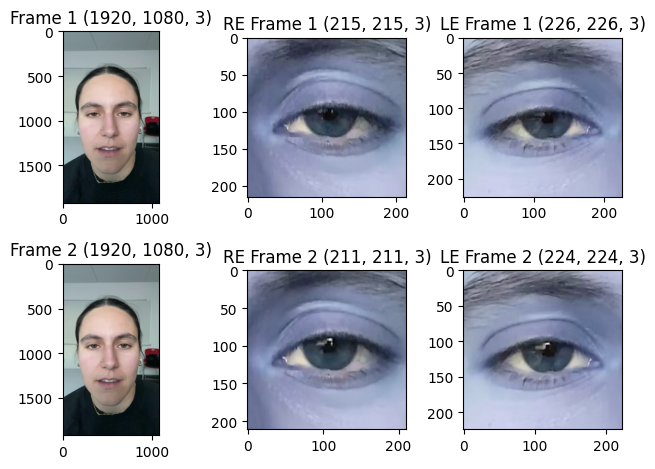

In [4]:

import numpy 
import cv2
import matplotlib.pyplot as plt

def old_isolate_eye_images(images, testing=False, saving=False):
# Function that takes in an array of face images and outputs two arrays of eye images (one for each eye)
# Input: 
#   images - An array of images (one for each video frame)
#   saving - Saves each cropped eye frame as a file if true
#   testing - Prints helpful outputs
# Outputs: 
#   right_eye_images: list of isolated, cropped images of the right eye for every frame
#   left_eye_images: list of isolated, cropped images of the left eye for every frame
    right_eye_images = list()
    left_eye_images = list()

    # Create output directory if it doesn't exist
    output_dir = './cropped_eyes/'
    os.makedirs(output_dir, exist_ok=True)
    
    for frame in range(0, images.shape[0]):

        # Convert to RGB for matplotlib display
        if testing:
            print(f'Image Frame #{frame} shape: {numpy.shape(images[frame])} \n\tand type: {numpy.dtype(images[frame, 0, 0, 0])}')

        image_rgb = cv2.cvtColor(images[frame], cv2.COLOR_BGR2RGB)
        # Convert to grayscale for detection
        gray = cv2.cvtColor(images[frame], cv2.COLOR_BGR2GRAY)
        
        # Load the pre-trained classifiers
        eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
        
        # Set x, y, w, h
        x = 0
        y = 0

        img_size = numpy.shape(gray)
        w = img_size[1]
        h = img_size[0]

        # Detect eyes in the face region with adjusted parameters
        eyes = eye_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=6,
            minSize=(int(w/12), int(h/12)),
            maxSize=(int(w/3), int(h/3))
        )
                
        # Sort eyes by x-coordinate to get left and right eye
        eyes = sorted(eyes, key=lambda x: x[0])
        
        # If we still don't have exactly 2 eyes, try to adjust detection
        if len(eyes) != 2:
            eyes = eye_cascade.detectMultiScale(
                gray,
                scaleFactor=1.05,
                minNeighbors=8,
                minSize=(int(w/12), int(h/12)),
                maxSize=(int(w/3), int(h/3))
            )
            eyes = sorted(eyes, key=lambda x: x[0])
            
        if len(eyes) < 2:
            raise ValueError(f"Could not detect both eyes properly in frame_{frame:04d}")
            
        # Take only the first two detected eyes
        eyes = eyes[:2]
        eye_images = []
        
        # Draw rectangles around eyes and crop them
        for i, (ex, ey, ew, eh) in enumerate(eyes):
            
            # Crop eye region
            eye_roi = image_rgb[y+ey:y+ey+eh, x+ex:x+ex+ew]
            eye_images.append(eye_roi)
            
            # Save eye image
            eye_type = "left" if i == 0 else "right"
            output_path = os.path.join(output_dir, f"frame_{frame:04d}_{eye_type}_eye.jpg")
            
            # Convert from RGB to BGR for cv2.imwrite
            eye_bgr = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2BGR)

            if saving:
                cv2.imwrite(output_path, eye_bgr)

            # add to list for output
            if eye_type == "left":
                left_eye_images.append(eye_bgr)
            else:
                right_eye_images.append(eye_bgr)


    return right_eye_images, left_eye_images

def isolate_eye_images(images, testing=False, saving=False):
# Function that takes in an array of face images and outputs two arrays of eye images (one for each eye)
# Input: 
#   images - An array of images (one for each video frame)
#   saving - Saves each cropped eye frame as a file if true
#   testing - Prints helpful outputs
# Outputs: 
#   right_eye_images: list of isolated, cropped images of the right eye for every frame
#   left_eye_images: list of isolated, cropped images of the left eye for every frame
    right_eye_images = list()
    left_eye_images = list()

    # Create output directory if it doesn't exist
    output_dir = './cropped_eyes/'
    os.makedirs(output_dir, exist_ok=True)
    
    for frame in range(0, images.shape[0]):

        # Convert to RGB for matplotlib display
        if testing:
            print(f'Image Frame #{frame} shape: {numpy.shape(images[frame])} \n\tand type: {numpy.dtype(images[frame, 0, 0, 0])}')

        image_rgb = cv2.cvtColor(images[frame], cv2.COLOR_BGR2RGB)
        # Convert to grayscale for detection
        gray = cv2.cvtColor(images[frame], cv2.COLOR_BGR2GRAY)
        
        # Load the pre-trained classifiers
        eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
        
        # Set x, y, w, h
        x = 0
        y = 0

        img_size = numpy.shape(gray)
        w = img_size[1]
        h = img_size[0]

        # Detect eyes in the face region with adjusted parameters
        eyes = eye_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=6,
            minSize=(int(w/12), int(h/12)),
            maxSize=(int(w/3), int(h/3))
        )
                
        # Sort eyes by x-coordinate to get left and right eye
        eyes = sorted(eyes, key=lambda x: x[0])
        
        # If we still don't have exactly 2 eyes, try to adjust detection
        if len(eyes) != 2:
            eyes = eye_cascade.detectMultiScale(
                gray,
                scaleFactor=1.05,
                minNeighbors=8,
                minSize=(int(w/12), int(h/12)),
                maxSize=(int(w/3), int(h/3))
            )
            eyes = sorted(eyes, key=lambda x: x[0])
            
        if len(eyes) < 2:
            raise ValueError(f"Could not detect both eyes properly in frame_{frame:04d}")
            
        # Take only the first two detected eyes
        eyes = eyes[:2]
        eye_images = []
        
        # Draw rectangles around eyes and crop them
        for i, (ex, ey, ew, eh) in enumerate(eyes):
            
            # Crop eye region
            eye_roi = image_rgb[y+ey:y+ey+eh, x+ex:x+ex+ew]
            eye_images.append(eye_roi)
            
            # Save eye image
            eye_type = "left" if i == 0 else "right"
            output_path = os.path.join(output_dir, f"frame_{frame:04d}_{eye_type}_eye.jpg")
            
            # Convert from RGB to BGR for cv2.imwrite
            eye_bgr = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2BGR)

            if saving:
                cv2.imwrite(output_path, eye_bgr)

            # add to list for output
            if eye_type == "left":
                left_eye_images.append(eye_bgr)
            else:
                right_eye_images.append(eye_bgr)


    return right_eye_images, left_eye_images


image = cv2.imread('./base_frames/frame_0000.jpg')
image2 = cv2.imread('./base_frames/frame_0001.jpg')

images = list()
images.append(image)
images.append(image2)
images = numpy.array(images)

corrected_image = numpy.zeros_like(image)
corrected_image[:,:,0] = image[:,:,2]
corrected_image[:,:,1] = image[:,:,1]
corrected_image[:,:,2] = image[:,:,0]

corrected_image2 = numpy.zeros_like(image2)
corrected_image2[:,:,0] = image2[:,:,2]
corrected_image2[:,:,1] = image2[:,:,1]
corrected_image2[:,:,2] = image2[:,:,0]

right_eyes, left_eyes = old_isolate_eye_images(images, testing=False, saving=True)

fig, ax = plt.subplots(2,3)
print(corrected_image.shape)
ax[0,0].imshow(corrected_image)
ax[0,0].set_title(f"Frame 1 {image.shape}")
ax[0,1].imshow(right_eyes[0], cmap='gray')
ax[0,1].set_title(f"RE Frame 1 {right_eyes[0].shape}")
ax[0,2].imshow(left_eyes[0], cmap='gray')
ax[0,2].set_title(f"LE Frame 1 {left_eyes[0].shape}")
ax[1,0].imshow(corrected_image2)
ax[1,0].set_title(f"Frame 2 {image2.shape}")
ax[1,1].imshow(right_eyes[1], cmap='gray')
ax[1,1].set_title(f"RE Frame 2 {right_eyes[1].shape}")
ax[1,2].imshow(left_eyes[1], cmap='gray')
ax[1,2].set_title(f"LE Frame 2 {left_eyes[1].shape}")
plt.tight_layout()

### Ethan To Do List

1. Update Eye Isolation Code using Mihir's 68 point method
2. Update NN to intake eyepoints and predicted measurements
3. Update "GUI To Get Data Function"


